In [25]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data  = data
        self.grad  = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op   = _op
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __sub__(self, other): 
        return self + (-other)
        
    def __neg__(self): 
        return self * -1

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): 
        return self.__mul__(other)

    def __pow__(self, n):
        assert isinstance(n, (int, float))
        out = Value(self.data ** n, (self,), f'**{n}')
        def _backward():
            self.grad += n * (self.data ** (n - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other ** -1
    def __rtruediv__(self, other): 
        return Value(other) * self ** -1

    def tanh(self):
        x  = self.data
        t  = math.tanh(x)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x  = self.data
        ex = math.exp(x)
        out = Value(ex, (self,), 'exp')
        def _backward():
            self.grad += ex * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'

In [26]:
# Basit test: (a * b + c) * f
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
f = Value(-2.0, label='f')
L = d * f;  L.label = 'L'

print(f'L.data = {L.data}   (beklenen: {(2.0 * -3.0 + 10.0) * -2.0})')
print(f'Parent node lar: {[v.label for v in L._prev]}')

L.data = -8.0   (beklenen: -8.0)
Parent node lar: ['d', 'f']


In [27]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
L = d * f;  L.label = 'L' #L=(a*b+c)*f 


# Elle atama
L.grad = 1.0
d.grad = f.data
f.grad = d.data
e.grad = d.grad * 1.0
c.grad = d.grad * 1.0
a.grad = e.grad * b.data
b.grad = e.grad * a.data

abs(node.grad - beklenen[name]) < 1e-6 
beklenen = {'L': 1.0, 'd': -2.0, 'f': 4.0, 'e': -2.0, 'c': -2.0, 'a': 6.0, 'b': -4.0}
for node, name in [(L,'L'),(d,'d'),(f,'f'),(e,'e'),(c,'c'),(a,'a'),(b,'b')]:
    ok = 'OK' if node.grad==beklenen[name] else 'HATALI'
    print(f'  dL/d{name} = {node.grad:+.4f}  [{ok}]')



  dL/dL = +1.0000  [OK]
  dL/dd = -2.0000  [OK]
  dL/df = +4.0000  [OK]
  dL/de = -2.0000  [OK]
  dL/dc = -2.0000  [OK]
  dL/da = +6.0000  [OK]
  dL/db = -4.0000  [OK]


In [28]:
x1 = Value(2.0,  label='x1')
x2 = Value(0.0,  label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
b  = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1;              x1w1.label = 'x1*w1'
x2w2 = x2 * w2;              x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2;     x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b;            n.label = 'n'
o = n.tanh();                 o.label = 'o'

print(f'n = {n.data:.6f}')
print(f'o = tanh(n) = {o.data:.6f}')

# Elle
o.grad = 1.0
n.grad  = (1 - o.data**2) * o.grad
b.grad  = 1.0 * n.grad
x1w1x2w2.grad = 1.0 * n.grad
x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

print('\nElle Hesaplanan Gradientler:')
for node, name in [(x1,'x1'),(w1,'w1'),(x2,'x2'),(w2,'w2'),(b,'b')]:
    print(f'  do/d{name} = {node.grad:+.6f}')


n = 0.881374
o = tanh(n) = 0.707107

Elle Hesaplanan Gradientler:
  do/dx1 = -1.500000
  do/dw1 = +1.000000
  do/dx2 = +0.500000
  do/dw2 = +0.000000
  do/db = +0.500000


In [29]:
# 3A: Basit ifade — backward() vs elle
a = Value(2.0, label='a'); b = Value(-3.0, label='b')
c = Value(10.0, label='c'); f = Value(-2.0, label='f')
e = a * b; e.label='e'; d = e + c; d.label='d'; L = d * f; L.label='L'

L.backward()

beklenen = {'a':6.0,'b':-4.0,'c':-2.0,'e':-2.0,'d':-2.0,'f':4.0,'L':1.0}
print('backward() ile hesaplanan gradient ler:')
for node, name in [(L,'L'),(d,'d'),(f,'f'),(e,'e'),(c,'c'),(a,'a'),(b,'b')]:
    ok = 'OK' if abs(node.grad - beklenen[name]) < 1e-6 else 'HATALI'
    print(f'  dL/d{name} = {node.grad:+.4f}  (beklenen {beklenen[name]:+.4f})  [{ok}]')

backward() ile hesaplanan gradient ler:
  dL/dL = +1.0000  (beklenen +1.0000)  [OK]
  dL/dd = -2.0000  (beklenen -2.0000)  [OK]
  dL/df = +4.0000  (beklenen +4.0000)  [OK]
  dL/de = -2.0000  (beklenen -2.0000)  [OK]
  dL/dc = -2.0000  (beklenen -2.0000)  [OK]
  dL/da = +6.0000  (beklenen +6.0000)  [OK]
  dL/db = -4.0000  (beklenen -4.0000)  [OK]


In [30]:
# 3B: Tek noron
x1 = Value(2.0, label='x1'); x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1'); w2 = Value(1.0, label='w2')
b  = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x2w2 = x2 * w2
n = x1w1 + x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

o.backward()

print('Tek noron backward() sonuclari:')
print(f'  x1.grad = {x1.grad:+.6f}  (beklenen: -1.500000)')
print(f'  w1.grad = {w1.grad:+.6f}  (beklenen:  1.000000)')
print(f'  x2.grad = {x2.grad:+.6f}  (beklenen:  0.500000)')
print(f'  w2.grad = {w2.grad:+.6f}  (beklenen:  0.000000)')



Tek noron backward() sonuclari:
  x1.grad = -1.500000  (beklenen: -1.500000)
  w1.grad = +1.000000  (beklenen:  1.000000)
  x2.grad = +0.500000  (beklenen:  0.500000)
  w2.grad = +0.000000  (beklenen:  0.000000)


In [31]:
# 3C: Gradient accumulation testi — a + a = 2a
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
print(f'a.grad = {a.grad}  (beklenen: 2.0) --- += olmasa 1 alirdik')

a.grad = 2.0  (beklenen: 2.0) --- += olmasa 1 alirdik


In [32]:
# Yontem 1: backward() — tanh PARCALANMIS
x1 = Value(2.0, label='x1'); x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1'); w2 = Value(1.0, label='w2')
b  = Value(6.8813735870195432, label='b')

n = x1 * w1 + x2 * w2 + b
e = (2 * n).exp()      # e^(2n)
o = (e - 1) / (e + 1)  # tanh(n) = (e^2n - 1) / (e^2n + 1)
o.label = 'o'

o.backward()

print('Yontem 1 — backward() (tanh parcalanmis):')
grad_back = {'x1': x1.grad, 'x2': x2.grad, 'w1': w1.grad, 'w2': w2.grad}
for k, v in grad_back.items():
    print(f'  do/d{k} = {v:+.8f}')

Yontem 1 — backward() (tanh parcalanmis):
  do/dx1 = -1.50000000
  do/dx2 = +0.50000000
  do/dw1 = +1.00000000
  do/dw2 = +0.00000000


In [33]:
# Yontem 2: Numerical derivative (merkezi farklar)
def forward_neuron(x1v, x2v, w1v, w2v, bv):
    return math.tanh(x1v*w1v + x2v*w2v + bv)

X1, X2, W1, W2, B = 2.0, 0.0, -3.0, 1.0, 6.8813735870195432
h = 1e-5

grad_num = {
    'x1': (forward_neuron(X1+h,X2,W1,W2,B) - forward_neuron(X1-h,X2,W1,W2,B)) / (2*h),
    'x2': (forward_neuron(X1,X2+h,W1,W2,B) - forward_neuron(X1,X2-h,W1,W2,B)) / (2*h),
    'w1': (forward_neuron(X1,X2,W1+h,W2,B) - forward_neuron(X1,X2,W1-h,W2,B)) / (2*h),
    'w2': (forward_neuron(X1,X2,W1,W2+h,B) - forward_neuron(X1,X2,W1,W2-h,B)) / (2*h),
}
print('Yontem 2 — Numerical Derivative:')
for k, v in grad_num.items():
    print(f'  do/d{k} = {v:+.8f}')

Yontem 2 — Numerical Derivative:
  do/dx1 = -1.50000000
  do/dx2 = +0.50000000
  do/dw1 = +1.00000000
  do/dw2 = +0.00000000


In [34]:
# Yontem 3: PyTorch autograd

import torch
x1_t = torch.tensor(2.0,  requires_grad=True)
x2_t = torch.tensor(0.0,  requires_grad=True)
w1_t = torch.tensor(-3.0, requires_grad=True)
w2_t = torch.tensor(1.0,  requires_grad=True)
b_t  = torch.tensor(6.8813735870195432, requires_grad=True)
n_t = x1_t * w1_t + x2_t * w2_t + b_t
o_t = torch.tanh(n_t)
o_t.backward()
grad_torch = {'x1': x1_t.grad.item(), 'x2': x2_t.grad.item(),
                'w1': w1_t.grad.item(), 'w2': w2_t.grad.item()}
print('Yontem 3 — PyTorch autograd:')
for k, v in grad_torch.items():
    print(f'  do/d{k} = {v:+.8f}')


Yontem 3 — PyTorch autograd:
  do/dx1 = -1.50000036
  do/dx2 = +0.50000012
  do/dw1 = +1.00000024
  do/dw2 = +0.00000000


In [35]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


random.seed(42)
mlp = MLP(3, [4, 4, 1])
print(f'Toplam parametre: {len(mlp.parameters())}')

Toplam parametre: 41


In [36]:
# Karpathy'nin kucuk veri seti
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

# Baslangic tahminleri
y_pred = [mlp(x) for x in xs]
print('Baslangic tahminleri:')
for i, (pred, target) in enumerate(zip(y_pred, ys)):
    print(f'  Ornek {i}: pred={pred.data:+.4f}, hedef={target:+.1f}')

Baslangic tahminleri:
  Ornek 0: pred=+0.6994, hedef=+1.0
  Ornek 1: pred=+0.5026, hedef=-1.0
  Ornek 2: pred=+0.6932, hedef=-1.0
  Ornek 3: pred=+0.8755, hedef=+1.0


In [37]:
# Egitim dongusu
import matplotlib.pyplot as plt

learning_rate = 0.05
epochs        = 100
loss_history  = []

for epoch in range(epochs):
    # 1. Forward pass
    y_pred = [mlp(x) for x in xs]

    # 2. Loss (MSE)
    loss = sum((y_out - Value(y_gt))**2 for y_out, y_gt in zip(y_pred, ys))
    loss_history.append(loss.data)

    # 3. Gradient sifirla  <-- KRITIK (bunu atlama!)
    mlp.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Gradient descent ile parametre guncelle
    for p in mlp.parameters():
        p.data -= learning_rate * p.grad

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs} | Loss: {loss.data:.6f}')

print('\nFinal tahminler vs hedefler:')
for i, (pred, target) in enumerate(zip([mlp(x) for x in xs], ys)):
    dogru = 'DOGRU' if (pred.data > 0) == (target > 0) else 'YANLIS'
    print(f'  Ornek {i}: pred={pred.data:+.4f}, hedef={target:+.1f}  [{dogru}]')

Epoch   1/100 | Loss: 5.230518
Epoch  10/100 | Loss: 0.246051
Epoch  20/100 | Loss: 0.090313
Epoch  30/100 | Loss: 0.052370
Epoch  40/100 | Loss: 0.036063
Epoch  50/100 | Loss: 0.027169
Epoch  60/100 | Loss: 0.021629
Epoch  70/100 | Loss: 0.017874
Epoch  80/100 | Loss: 0.015174
Epoch  90/100 | Loss: 0.013146
Epoch 100/100 | Loss: 0.011572

Final tahminler vs hedefler:
  Ornek 0: pred=+0.9455, hedef=+1.0  [DOGRU]
  Ornek 1: pred=-0.9654, hedef=-1.0  [DOGRU]
  Ornek 2: pred=-0.9303, hedef=-1.0  [DOGRU]
  Ornek 3: pred=+0.9509, hedef=+1.0  [DOGRU]


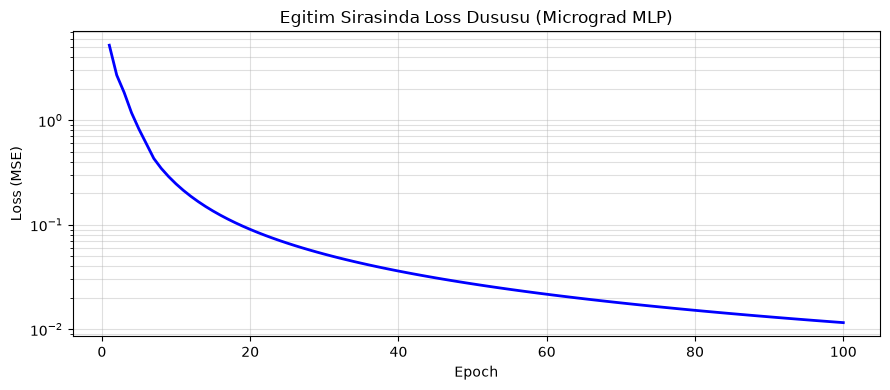

In [38]:
# Loss duşus egrisi
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), loss_history, 'b-', linewidth=2)
plt.title('Egitim Sirasinda Loss Dususu (Micrograd MLP)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()